In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("C:\\Users\\devad\\Downloads\\loli\\Machine_Learning_project\\Mahine-learning-revisit\\Project2_Crypto_Price_Prediction\\datasets\\crypto_price_dirty.csv")
df

,CoinName,Open,High,Low,Volume_M,MarketCap_B,RSI,MACD,SentimentScore,DayOfWeek,NewsCount,Close
0,BNB,NaN,262.87,250.50,11.11,6.31,33.83,-154.59,-0.787,1.0,19,260.44
1,Bitcoin,37210.13,39484.50,35394.53,8.31,835.21,50.65,119.59,-0.167,2.0,3,36714.62
2,BNB,44110.58,46907.57,40602.50,6.56,826.82,76.49,389.96,0.537,2.0,8,45759.21
3,Solana,101.58,108.36,98.93,29.31,2.04,64.81,-198.59,-0.024,4.0,3,98.91
4,BNB,265.85,269.37,258.58,48.21,5.72,36.45,-78.84,-0.567,1.0,22,262.40
...,...,...,...,...,...,...,...,...,...,...,...,...
1016,XRP,0.53,0.56,0.51,36.91,0.01,25.21,-398.20,0.773,4.0,6,0.80
1017,XRP,0.55,0.55,0.51,12.68,0.01,NaN,251.81,-0.166,5.0,22,1.11
1018,Solana,97.19,99.08,97.14,10.41,1.76,78.86,-133.48,-0.295,6.0,5,94.36
1019,Bitcoin,2118624.00,43415.35,40377.08,35.23,793.34,64.15,-74.20,-0.870,2.0,13,40276.33


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CoinName        1021 non-null   object 
 1   Open            937 non-null    float64
 2   High            1021 non-null   float64
 3   Low             1021 non-null   float64
 4   Volume_M        947 non-null    float64
 5   MarketCap_B     1021 non-null   float64
 6   RSI             941 non-null    float64
 7   MACD            1021 non-null   float64
 8   SentimentScore  947 non-null    float64
 9   DayOfWeek       946 non-null    float64
 10  NewsCount       1021 non-null   int64  
 11  Close           957 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 95.8+ KB


In [4]:
len(df)

1021

In [5]:
df.describe()

,Open,High,Low,Volume_M,MarketCap_B,RSI,MACD,SentimentScore,DayOfWeek,NewsCount,Close
count,9.370000e+02,1021.000000,1021.000000,947.000000,1021.000000,941.000000,1021.000000,947.000000,946.000000,1021.000000,9.570000e+02
mean,2.086001e+04,8082.092204,7439.722840,26.303105,147.223565,52.742136,-4.319236,0.014158,3.103594,14.785504,2.158149e+04
std,1.566591e+05,15866.866773,14603.383116,14.406618,288.544794,24.547784,288.405520,0.583047,1.997842,8.894812,2.395683e+05
min,4.300000e-01,0.440000,0.400000,0.510000,0.010000,20.010000,-498.690000,-0.998000,0.000000,0.000000,6.600000e-01
25%,9.113000e+01,94.630000,87.230000,13.625000,1.800000,35.190000,-252.250000,-0.503500,1.000000,7.000000,9.214000e+01
50%,3.025100e+02,312.250000,288.750000,26.750000,5.640000,50.390000,-15.210000,0.021000,3.000000,15.000000,3.047600e+02
75%,2.691360e+03,2735.290000,2523.380000,39.135000,49.130000,67.310000,248.760000,0.509500,5.000000,23.000000,2.667640e+03
max,2.118624e+06,48783.550000,45754.360000,49.970000,878.870000,195.520000,498.340000,0.998000,6.000000,30.000000,4.526135e+06


In [6]:
df.isna().sum()[df.isna().sum()>0]

Open              84
Volume_M          74
RSI               80
SentimentScore    74
DayOfWeek         75
Close             64
dtype: int64

In [7]:
df.CoinName.unique()

array(['BNB', 'Bitcoin', 'Solana', 'Ethereum', 'bitcoin', 'XRP',
       'etherum', 'Etherium', 'bnb', 'ETH', 'BITCOIN'], dtype=object)

In [8]:
coin_map={
    'bitcoin':'Bitcoin',
    'ethereum':'Ethereum',
    'etherum':'Ethereum',
    'Etherium':'Ethereum',
    'bnb':'BNB',
    'ETH':'Ethereum',
    'BITCOIN':'Bitcoin',
    'XRP':'XRP',
    'Solana':'Solana'
}
df.CoinName.replace(coin_map,inplace=True)
df.loc[~df.CoinName.isin(coin_map.values()),'CoinName']=np.nan
df.CoinName.unique()

C:\Users\devad\AppData\Local\Temp\ipykernel_26600\2022933431.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.CoinName.replace(coin_map,inplace=True)


array(['BNB', 'Bitcoin', 'Solana', 'Ethereum', 'XRP'], dtype=object)

In [9]:
df.loc[(df.RSI <0) | (df.RSI >100),'RSI']=np.nan
df.RSI.describe()

count    914.000000
mean      49.878643
std       17.600378
min       20.010000
25%       34.955000
50%       49.245000
75%       65.717500
max       79.970000
Name: RSI, dtype: float64

In [10]:
corr = df.select_dtypes(include=np.number).corr()['Close'].sort_values(ascending=False)
corr

Close             1.000000
High              0.186114
Low               0.184558
MarketCap_B       0.182140
Volume_M          0.039575
Open              0.024855
SentimentScore    0.021109
RSI               0.007935
MACD             -0.002006
DayOfWeek        -0.017925
NewsCount        -0.052073
Name: Close, dtype: float64

In [11]:
df.loc[(df.DayOfWeek <0) | (df.DayOfWeek >6),'DayOfWeek']=np.nan
df.DayOfWeek.describe()

count    946.000000
mean       3.103594
std        1.997842
min        0.000000
25%        1.000000
50%        3.000000
75%        5.000000
max        6.000000
Name: DayOfWeek, dtype: float64

In [12]:
df.columns

Index(['CoinName', 'Open', 'High', 'Low', 'Volume_M', 'MarketCap_B', 'RSI',
       'MACD', 'SentimentScore', 'DayOfWeek', 'NewsCount', 'Close'],
      dtype='object')

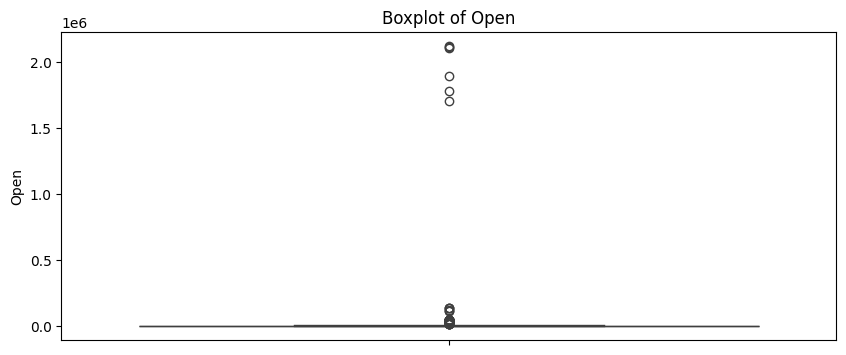

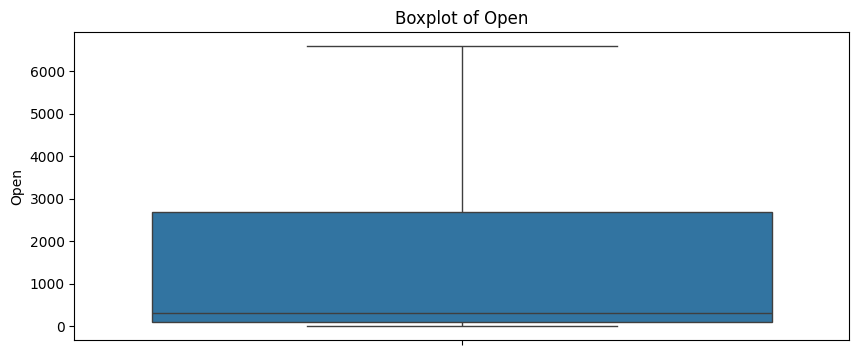

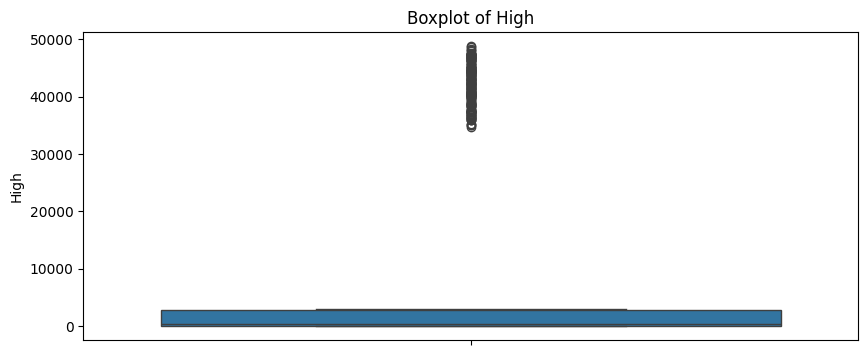

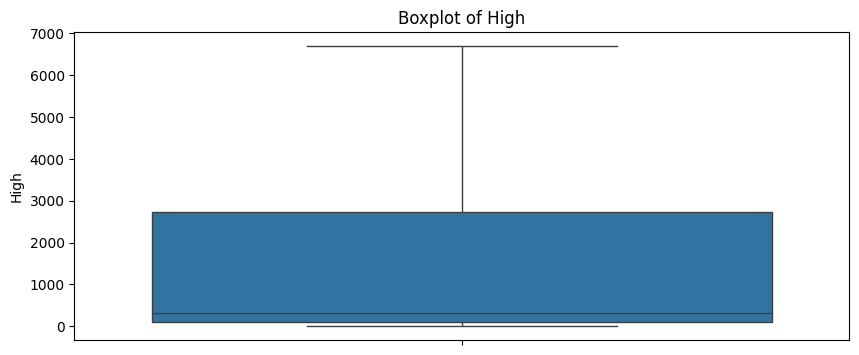

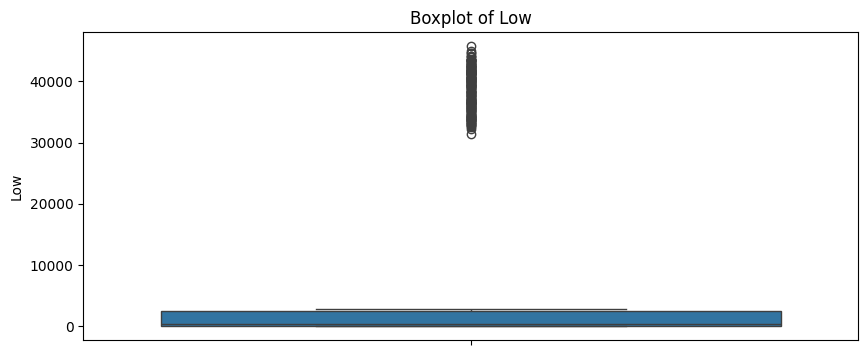

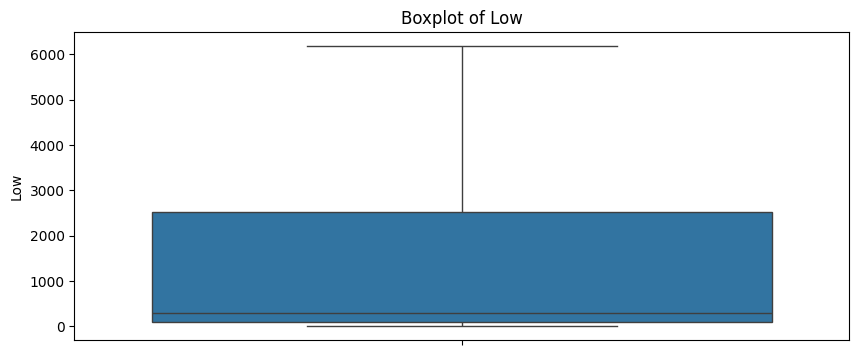

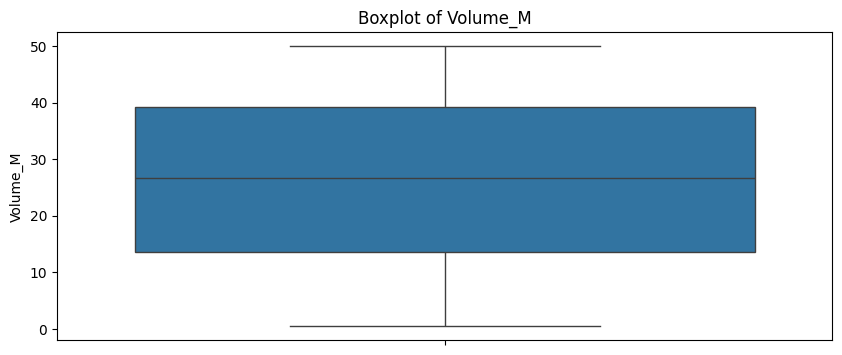

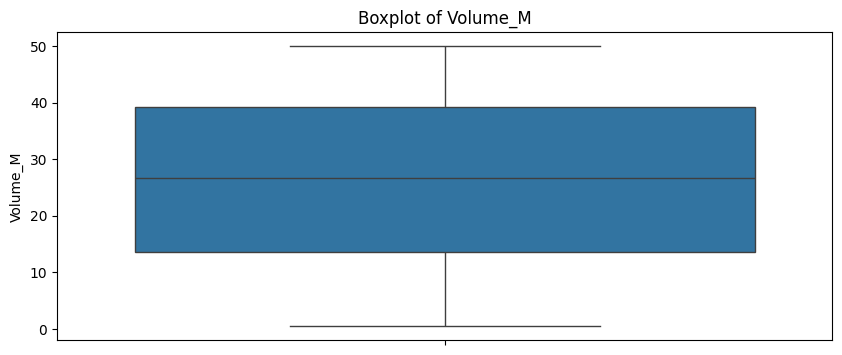

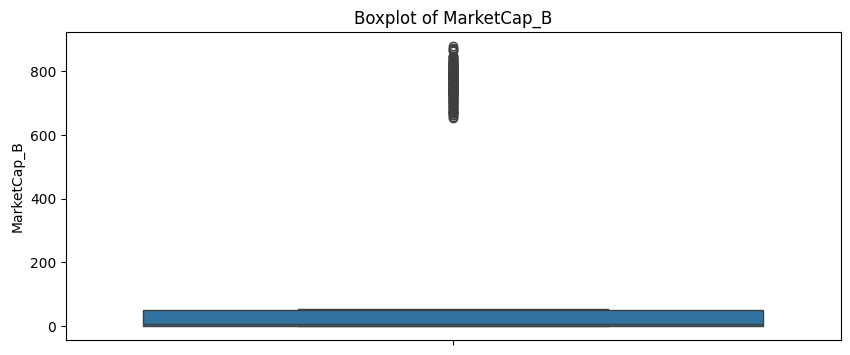

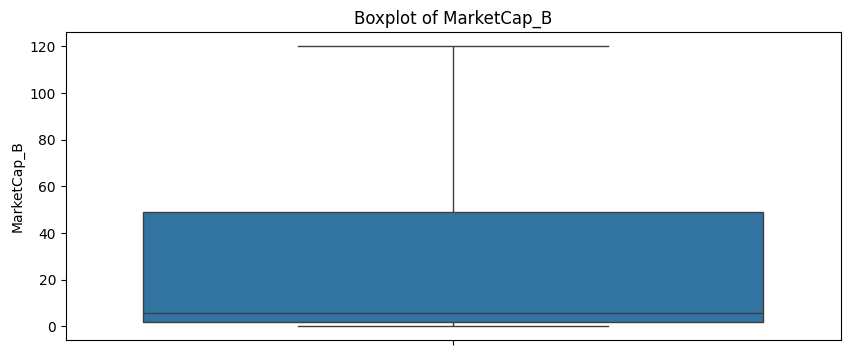

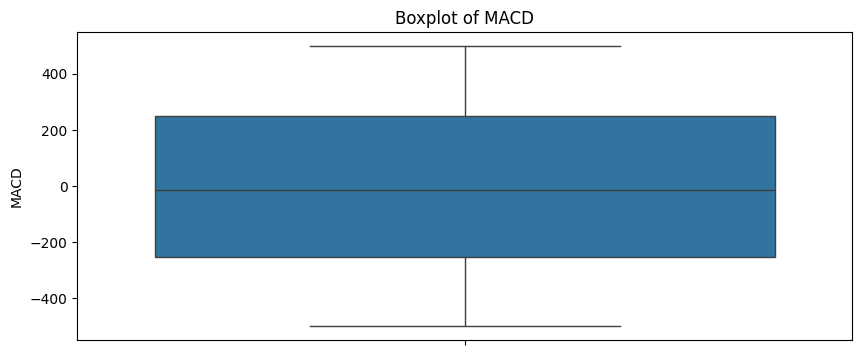

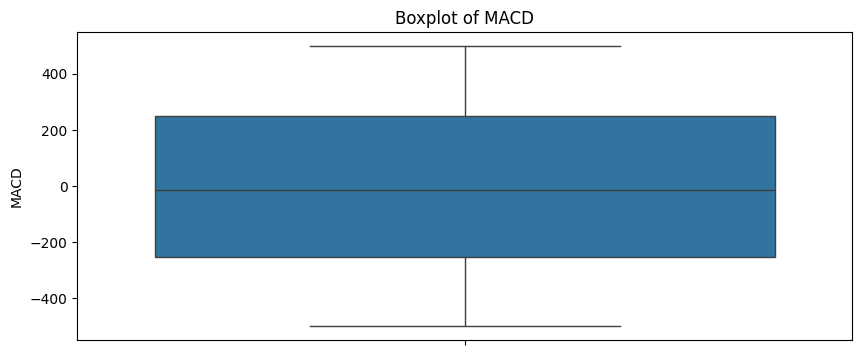

In [13]:
# outliers handling
skip_columns=['DayOfWeek','RSI','NewsCount','SentimentScore','Close']
for col in df.select_dtypes(include=np.number).columns:
    if col not in skip_columns:
        plt.figure(figsize=(10,4))
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot of {col}')
        plt.show()
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR
        df[col]=np.where(df[col] <lower_bound,lower_bound,np.where(df[col]>upper_bound,upper_bound,df[col]))
        plt.figure(figsize=(10,4))
        sns.boxplot(y=df[col])
        plt.title(f'Boxplot of {col}')
        plt.show()
        
        
        

In [14]:
df.loc[(df.SentimentScore < -1) | (df.SentimentScore >1),'SentimentScore']=np.nan   

In [15]:
df.isna().sum()[df.isna().sum()>0]

Open               84
Volume_M           74
RSI               107
SentimentScore     74
DayOfWeek          75
Close              64
dtype: int64

In [16]:
df.dtypes

CoinName           object
Open              float64
High              float64
Low               float64
Volume_M          float64
MarketCap_B       float64
RSI               float64
MACD              float64
SentimentScore    float64
DayOfWeek         float64
NewsCount           int64
Close             float64
dtype: object

In [17]:
for col in df.columns:
    if (df[col].dtype=='object') & (df[col].isna().sum()>0):
        df[col].fillna(df[col].mode()[0],inplace=True)
    elif (df[col].dtype in ['int64','float64']) & (df[col].isna().sum()>0):
        df[col].fillna(df[col].median(),inplace=True)

C:\Users\devad\AppData\Local\Temp\ipykernel_26600\737020078.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)
C:\Users\devad\AppData\Local\Temp\ipykernel_26600\737020078.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

In [18]:
df.isna().sum()[df.isna().sum()>0]

Series([], dtype: int64)

In [19]:
# feature engineering
conditions = [
    df['RSI'] < 30,
    (df['RSI'] >= 30) & (df['RSI'] <= 70),
    df['RSI'] > 70
]
choices = [0, 1, 2]   # 0=Oversold, 1=Neutral, 2=Overbought
df['RSI_Zone'] = np.select(conditions, choices, default=1)
print("[New Feature] RSI_Zone → 0=Oversold, 1=Neutral, 2=Overbought")

[New Feature] RSI_Zone → 0=Oversold, 1=Neutral, 2=Overbought


In [20]:
df['IsWeekend']=df.DayOfWeek.apply(lambda x: x in [5,6]).astype(int)

In [21]:
df

,CoinName,Open,High,Low,Volume_M,MarketCap_B,RSI,MACD,SentimentScore,DayOfWeek,NewsCount,Close,RSI_Zone,IsWeekend
0,BNB,302.510,262.87,250.500,11.11,6.310,33.830,-154.59,-0.787,1.0,19,260.44,1,0
1,Bitcoin,6591.705,6696.28,6177.605,8.31,120.125,50.650,119.59,-0.167,2.0,3,36714.62,1,0
2,BNB,6591.705,6696.28,6177.605,6.56,120.125,76.490,389.96,0.537,2.0,8,45759.21,2,0
3,Solana,101.580,108.36,98.930,29.31,2.040,64.810,-198.59,-0.024,4.0,3,98.91,1,0
4,BNB,265.850,269.37,258.580,48.21,5.720,36.450,-78.84,-0.567,1.0,22,262.40,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016,XRP,0.530,0.56,0.510,36.91,0.010,25.210,-398.20,0.773,4.0,6,0.80,0,0
1017,XRP,0.550,0.55,0.510,12.68,0.010,49.245,251.81,-0.166,5.0,22,1.11,1,1
1018,Solana,97.190,99.08,97.140,10.41,1.760,78.860,-133.48,-0.295,6.0,5,94.36,2,1
1019,Bitcoin,6591.705,6696.28,6177.605,35.23,120.125,64.150,-74.20,-0.870,2.0,13,40276.33,1,0


In [22]:
dummies=pd.get_dummies(df.CoinName,drop_first=True,dtype=int)
dummies
df.drop('CoinName',axis=1,inplace=True)
df1=pd.concat([df,dummies],axis=1)

In [23]:
df1

,Open,High,Low,Volume_M,MarketCap_B,RSI,MACD,SentimentScore,DayOfWeek,NewsCount,Close,RSI_Zone,IsWeekend,Bitcoin,Ethereum,Solana,XRP
0,302.510,262.87,250.500,11.11,6.310,33.830,-154.59,-0.787,1.0,19,260.44,1,0,0,0,0,0
1,6591.705,6696.28,6177.605,8.31,120.125,50.650,119.59,-0.167,2.0,3,36714.62,1,0,1,0,0,0
2,6591.705,6696.28,6177.605,6.56,120.125,76.490,389.96,0.537,2.0,8,45759.21,2,0,0,0,0,0
3,101.580,108.36,98.930,29.31,2.040,64.810,-198.59,-0.024,4.0,3,98.91,1,0,0,0,1,0
4,265.850,269.37,258.580,48.21,5.720,36.450,-78.84,-0.567,1.0,22,262.40,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016,0.530,0.56,0.510,36.91,0.010,25.210,-398.20,0.773,4.0,6,0.80,0,0,0,0,0,1
1017,0.550,0.55,0.510,12.68,0.010,49.245,251.81,-0.166,5.0,22,1.11,1,1,0,0,0,1
1018,97.190,99.08,97.140,10.41,1.760,78.860,-133.48,-0.295,6.0,5,94.36,2,1,0,0,1,0
1019,6591.705,6696.28,6177.605,35.23,120.125,64.150,-74.20,-0.870,2.0,13,40276.33,1,0,1,0,0,0


In [24]:
x=df1.drop('Close',axis=1)
y=df1.Close

In [25]:
x

,Open,High,Low,Volume_M,MarketCap_B,RSI,MACD,SentimentScore,DayOfWeek,NewsCount,RSI_Zone,IsWeekend,Bitcoin,Ethereum,Solana,XRP
0,302.510,262.87,250.500,11.11,6.310,33.830,-154.59,-0.787,1.0,19,1,0,0,0,0,0
1,6591.705,6696.28,6177.605,8.31,120.125,50.650,119.59,-0.167,2.0,3,1,0,1,0,0,0
2,6591.705,6696.28,6177.605,6.56,120.125,76.490,389.96,0.537,2.0,8,2,0,0,0,0,0
3,101.580,108.36,98.930,29.31,2.040,64.810,-198.59,-0.024,4.0,3,1,0,0,0,1,0
4,265.850,269.37,258.580,48.21,5.720,36.450,-78.84,-0.567,1.0,22,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016,0.530,0.56,0.510,36.91,0.010,25.210,-398.20,0.773,4.0,6,0,0,0,0,0,1
1017,0.550,0.55,0.510,12.68,0.010,49.245,251.81,-0.166,5.0,22,1,1,0,0,0,1
1018,97.190,99.08,97.140,10.41,1.760,78.860,-133.48,-0.295,6.0,5,2,1,0,0,1,0
1019,6591.705,6696.28,6177.605,35.23,120.125,64.150,-74.20,-0.870,2.0,13,1,0,1,0,0,0


In [26]:
y

0         260.44
1       36714.62
2       45759.21
3          98.91
4         262.40
          ...   
1016        0.80
1017        1.11
1018       94.36
1019    40276.33
1020       90.27
Name: Close, Length: 1021, dtype: float64

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [28]:
# normalization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [29]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error


In [30]:
models = {
    'Linear Regression': {
        'model' : LinearRegression(),
        'search': None,   # no hyperparameters to tune
        'params': {}
    },
    'Ridge': {
        'model' : Ridge(),
        'search': 'grid',
        'params': {
            'alpha'  : [0.01, 0.1, 1, 10, 100],
            'solver' : ['auto', 'svd', 'cholesky'],
        }
    },
    'Lasso': {
        'model' : Lasso(),
        'search': 'grid',
        'params': {
            'alpha'   : [0.001, 0.01, 0.1, 1, 10],
            'max_iter': [1000, 5000],
        }
    },
    'Decision Tree': {
        'model' : DecisionTreeRegressor(random_state=42),
        'search': 'grid',
        'params': {
            'max_depth'        : [3, 5, 7, 10, None],
            'min_samples_split': [2, 5, 10],
            'criterion'        : ['squared_error', 'absolute_error'],
        }
    },
    'Random Forest': {
        'model' : RandomForestRegressor(random_state=42),
        'search': 'random',
        'params': {
            'n_estimators'     : [50, 100, 200],
            'max_depth'        : [5, 10, 15, None],
            'min_samples_split': [2, 5, 10],
            'max_features'     : ['sqrt', 'log2'],
        }
    },
    'Gradient Boosting': {
        'model' : GradientBoostingRegressor(random_state=42),
        'search': 'random',
        'params': {
            'n_estimators' : [50, 100, 200],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth'    : [2, 3, 4, 5],
            'subsample'    : [0.6, 0.8, 1.0],
        }
    },
}

In [31]:
for name,config in  models.items():
    model=config['model']
    search=config['search']
    params=config['params']
    if search=='grid':
        gs=GridSearchCV(model,params,cv=5,scoring='neg_mean_squared_error',n_jobs=-1)
        gs.fit(x_train,y_train)
        best_model=gs.best_estimator_
        best_params=gs.best_params_
        best_cv=gs.best_score_
        y_pred=best_model.predict(x_test)
    else:
        rs=RandomizedSearchCV(model,params,scoring='neg_mean_squared_error',n_jobs=-1,cv=5,n_iter=20,random_state=42)
        rs.fit(x_train,y_train)
        best_models=rs.best_estimator_
        best_params=rs.best_params_
        best_cv=rs.best_score_
        y_pred=best_models.predict(x_test)
    mse=mean_squared_error(y_test,y_pred)
    r2=r2_score(y_test,y_pred)
    mae=mean_absolute_error(y_test,y_pred)
    rmse=np.sqrt(mse)
    print(f"\n📌 {name}")
    print(f"   MAE       : {mae:.4f}")
    print(f"   RMSE      : {rmse:.4f}")
    print(f"   R2 Score  : {r2:.4f}")
    print(f"   Best Params: {best_params}")

c:\Users\devad\Downloads\loli\Machine_Learning_project\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=20. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



📌 Linear Regression
   MAE       : 49774.2167
   RMSE      : 315832.6670
   R2 Score  : 0.0001
   Best Params: {}

📌 Ridge
   MAE       : 47185.4506
   RMSE      : 314943.5654
   R2 Score  : 0.0057
   Best Params: {'alpha': 100, 'solver': 'auto'}

📌 Lasso
   MAE       : 49768.7383
   RMSE      : 315829.7465
   R2 Score  : 0.0001
   Best Params: {'alpha': 10, 'max_iter': 1000}

📌 Decision Tree
   MAE       : 25225.4186
   RMSE      : 314004.3865
   R2 Score  : 0.0117
   Best Params: {'criterion': 'absolute_error', 'max_depth': 3, 'min_samples_split': 2}

📌 Random Forest
   MAE       : 35503.4027
   RMSE      : 316640.5676
   R2 Score  : -0.0050
   Best Params: {'n_estimators': 50, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': None}

📌 Gradient Boosting
   MAE       : 52576.5366
   RMSE      : 340198.7933
   R2 Score  : -0.1601
   Best Params: {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.1}
